In [56]:
import sys
import os
from pathlib import Path
import time

import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import torch
from torchvision.transforms import v2
from torchvision.io import decode_image
from joblib import Parallel, delayed

plt.ioff()

In [57]:
class Sample:
    """Class that contains relevant data of a sample investigated with profilometer"""
    # Conversion factor
    UM2MM = 1e-3
    
    def __init__(self, data_path, time, sample_id):
        self.data_path = data_path
        self.sample_id = sample_id
        
        # Read metadata from CSV
        height_path = data_path / time / "height" / f"{sample_id}.csv"
        with open(height_path, 'r') as file:
            for _ in range(21):
                line = next(file).strip().replace('"', '').split(",")
    
                if line[0] == "XY calibration":
                    # Convert from um to mm
                    self.pixel_size = float(line[1]) * Sample.UM2MM
                if line[0] == "Horizontal":
                    self.horizontal = int(line[1])
                if line[0] == "Vertical":
                    self.vertical = int(line[1])
                if line[0] == "Unit":
                    self.unit = line[1]
        
        # Read height profile of sample from CSV
        height = np.genfromtxt(height_path, skip_header=23, delimiter=",", dtype=str)
        height = np.char.strip(height, '"')
        height[height == ''] = np.nan
        self.height = height.astype(float)

        # Read profilometer image from PNG file
        image_path = data_path / time / "profilometer" / f"{sample_id}.png"
        self.image = cv.imread(image_path, cv.IMREAD_COLOR)

In [58]:
def get_sample_patch(image, extent):
    """Get patch contained in sample for backprojection"""
    return image[int(image.shape[0] * (0.5 - extent/2)):int(image.shape[0] * (0.5 + extent/2)), int(image.shape[1] * (0.5 - extent/2)):int(image.shape[1] * (0.5 + extent/2))]

def get_corner_patches(image, extent):
    """Get patch not contained in sample for backprojection"""
    upper_left = image[:int(image.shape[0] * extent),:int(image.shape[1] * extent)]
    upper_right = image[:int(image.shape[0] * extent),int(image.shape[1] - image.shape[1] * extent):]
    lower_left = image[int(image.shape[0] - image.shape[0] * extent):,:int(image.shape[1] * extent)]
    lower_right = image[int(image.shape[0] - image.shape[0] * extent):,int(image.shape[1] - image.shape[1] * extent):]
    
    return (upper_left, upper_right, lower_left, lower_right)

In [59]:
def backproject(target_image, roi_images, excluded_axis, inverse):
    """Backproject with patch examples to identify magensium sample"""
    # Range of HSV colors
    hsv_bins = np.array([180, 256, 256])
    # Possible image channels
    channels = [0, 1, 2]
    # Get channels of interest
    channels.remove(excluded_axis)

    # Determine bin numbers and ranges
    bins = hsv_bins[channels]
    ranges = [0, int(bins[0]), 0, int(bins[1])]

    # Backproject against normalized histogram of region of interest
    roi_hist = cv.calcHist(roi_images, channels, None, bins, ranges)
    cv.normalize(roi_hist ,roi_hist ,0 ,255, cv.NORM_MINMAX)
    projected = cv.equalizeHist(cv.calcBackProject([target_image], channels, roi_hist, ranges, 1))
    
    # If background roi was used inverse the result image
    if inverse:
        return cv.bitwise_not(projected)
    else:
        return projected
    

In [60]:
def mean_projected_image(image, sample_patch_extent=0.4, corner_patch_extent=0.2):
    """Calculate the mean of all backprojections to determine magensium sample"""
    hsv_image = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    projected_images = []
    
    for inverse in [False, True]:
        
        if not inverse:
            roi_images = [get_sample_patch(hsv_image, sample_patch_extent)]
        else:
            roi_images = get_corner_patches(hsv_image, corner_patch_extent)
        
        for channel in range(3):
            projected_images.append(backproject(hsv_image, roi_images, channel, inverse))    
    
    projected_images = np.array(projected_images)
    return projected_images.mean(axis=0).astype(np.uint8)

In [61]:
def postprocess_projected_image(mean_projected_image):
    """Create binary map that segments magnesium from background"""
    _, thresh = cv.threshold(mean_projected_image,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
    opened = cv.morphologyEx(src=thresh, op=cv.MORPH_OPEN, kernel=np.ones((3,3),np.uint8))
    return cv.morphologyEx(src=thresh, op=cv.MORPH_CLOSE, kernel=np.ones((3,3),np.uint8))

# return cv.morphologyEx(src=thresh, op=cv.MORPH_OPEN, kernel=np.ones((3,3),np.uint8))


In [62]:
def center_image(image, center):
    """Roll image so that provided center point is the new center of the image"""
    # copied_image = image.copy()
    image_center = (np.array(image.shape)/2).astype(int)
    center_offset = image_center - center
    shifted_image = np.roll(image, center_offset[0], axis=0)
    shifted_image = np.roll(shifted_image, center_offset[1], axis=1)
    return shifted_image


In [63]:
def calc_correlation(image):
    """Calc correlation between the mirros of the image"""
    correlated_image = image.copy()
    for i in [-1, 0, 1]:
        correlated_image *= cv.flip(image, i)
    return np.mean(correlated_image)

In [64]:
def calc_rotate_product(image, angle=60):
    """Rotate the image around center and multiply"""
    correlated_image = image.copy()
    for angle in range(angle, 360, angle):
        rotate_matrix = cv.getRotationMatrix2D(center=(correlated_image.shape[1]/2, correlated_image.shape[0]/2), angle=angle, scale=1)
        rotated_image = cv.warpAffine(image, rotate_matrix, correlated_image.shape[::-1])
        correlated_image *= rotated_image
    return correlated_image

In [65]:
def get_max_correlation(image, center_proposal, search_range, search_step):
    """Determine point of max multiplication correlation between differently shifted images and mirrored images"""
    # Create array to store correlation result for each shift of image
    correlation_result = np.empty(search_range + 1)

    # Define the ranges the image is shifted over
    x_range = np.arange(center_proposal[0] - (search_range[0]/2) * search_step, center_proposal[0] + (search_range[0]/2 + 1) * search_step, search_step, dtype=int)
    y_range = np.arange(center_proposal[1] - (search_range[1]/2) * search_step, center_proposal[1] + (search_range[1]/2 + 1) * search_step, search_step, dtype=int)
    
    for x_corr_index, x_center_index in enumerate(x_range):
        for y_corr_index, y_center_index in enumerate(y_range):
            # Shift the image so center_index is in center, than flip image around center and calc correlation            
            correlation_result[x_corr_index, y_corr_index] = calc_correlation(center_image(image, (x_center_index, y_center_index)))

    # Get pixel position of image, where correlation is maximized
    max_position_array = np.unravel_index(np.argmax(correlation_result), correlation_result.shape)
    return x_range[max_position_array[0]], y_range[max_position_array[1]]
    

In [66]:
def determine_circle_center(image):
    """Determine center of magensium sample from circular symmetry"""
    center_proposal = (np.array(image.shape)/2).astype(int)

    search_range = (np.array(image.shape)/(2 * 100)).astype(int)
    search_step = 100
    center_proposal = get_max_correlation(image, center_proposal, search_range, search_step)
    
    search_step = 20
    search_range = np.array((10, 10))
    center_proposal = get_max_correlation(image, center_proposal, search_range, search_step)
    
    search_step = 10
    search_range = np.array((10, 10))
    center_proposal = get_max_correlation(image, center_proposal, search_range, search_step)
    
    search_step = 1
    search_range = np.array((10, 10))
    center_proposal = get_max_correlation(image, center_proposal, search_range, search_step)

    return center_proposal


In [67]:
def create_circular_mask(w, h, center=None, radius=None):
    """Create a circular mask"""
    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    X, Y = np.ogrid[:w, :h]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

In [68]:
def determine_radius(image, center, side="outer", rotation_angle=60):
    """
    Determine the radius of the magnesium probe by rotation around
    its center and multiplicaton with itsel. Then take the inner
    part as boundary.
    """
    radii = np.array(range(600,700)).astype(int)
    intensity_array = np.empty_like(radii)
    
    if side == "outer":
        rotation_image = calc_rotate_product(np.invert(center_image(image, center)), angle=rotation_angle)
    elif side == "inner":
        rotation_image = calc_rotate_product(center_image(image, center), angle=rotation_angle)

    for rad_index, proposed_rad in enumerate(radii):
        inner_mask = create_circular_mask(rotation_image.shape[0], rotation_image.shape[1], radius=proposed_rad)
        outer_mask = create_circular_mask(rotation_image.shape[0], rotation_image.shape[1], radius=proposed_rad + 5)
        masked = rotation_image.copy().astype(float)
        masked[~outer_mask] = np.nan
        masked[inner_mask] = np.nan
        intensity_array[rad_index] = np.nansum(masked)

    if side == "outer":
        return radii[np.where(intensity_array == intensity_array.min())[0][-1]]
    elif side == "inner":
        return radii[np.argmin(intensity_array)]
    


In [69]:
def show_circle(image, circle):
    """Draw circle center and circle radius into sample image"""
    fig, ax = plt.subplots()
    ax.imshow(image)
    circ1 = patches.Circle(circle[:2][::-1], 10, linewidth=1, edgecolor='r', facecolor='none')
    circ2 = patches.Circle(circle[:2][::-1], circle[-1], linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(circ1)
    ax.add_patch(circ2)
    plt.show()


In [70]:
def determine_circle(path, time, ident, add_rad=40, save_path="sample-masking/circle-image"):
    sample = Sample(path, time, ident)
    projected_image = mean_projected_image(sample.image)
    postprocessed_image = postprocess_projected_image(projected_image)
    center = determine_circle_center(postprocessed_image)
    radius = determine_radius(postprocessed_image, center, side="outer")

    fig, ax = plt.subplots()
    ax.imshow(sample.image)
    circ1 = patches.Circle(center[::-1], 10, linewidth=1, edgecolor='r', facecolor='none')
    circ2 = patches.Circle(center[::-1], radius + add_rad, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(circ1)
    ax.add_patch(circ2)
    plt.savefig(path / time / save_path / f"{ident}.png")
    plt.close(fig)
    # plt.show()
    
    return (ident, *center, radius + add_rad)
    

In [71]:
path = Path("/data/dust/user/dammal/beegfs.migration/repos/ai2/data/processed")
time = "before"
sample_ids = [i.replace(".png", "") for i in os.listdir(path / time / "profilometer")]
ncpu = os.cpu_count()

In [ ]:
circles = Parallel(n_jobs=ncpu)(delayed(determine_circle)(path, time, ident) for ident in sample_ids)

In [ ]:
circle_df = pd.DataFrame(circles, columns=['id', 'x', 'y', 'r'])
circle_df.to_csv(path / "before/sample-masking/circle-list/circle-list.csv", index=False)
circle_df

In [ ]:
path = Path("/data/dust/user/dammal/beegfs.migration/repos/ai2/data/processed/")
time = "before"
bad_sample_ids = [i.replace(".png", "") for i in os.listdir(path / time / "sample-masking/circle-image/bad/")]

In [ ]:
new_circles = Parallel(n_jobs=ncpu)(delayed(determine_circle)(path, time, ident, add_rad=80, save_path="sample-masking/circle-image2") for ident in bad_sample_ids)

In [ ]:
new_circle_df = pd.DataFrame(new_circles, columns=['id', 'x', 'y', 'r'])
circle_df.update(new_circle_df)
circle_df.to_csv(path / "before/sample-masking/circle-list/circle-list.csv", index=False)
circle_df

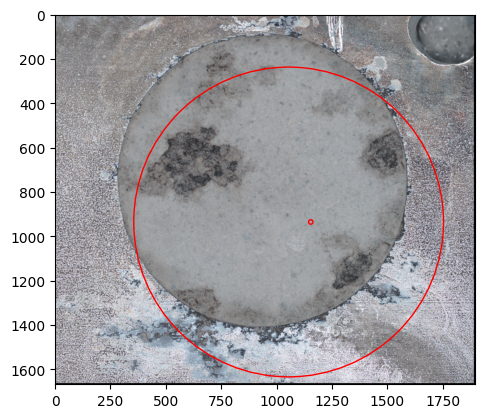

In [55]:
image_nr = 0

path = Path("/data/dust/user/dammal/beegfs.migration/repos/ai2/data/processed/")
time = "before"
bad_sample_ids = [i.replace(".png", "") for i in os.listdir(path / time / "sample-masking/circle-image2/bad/")]

sample = Sample(path, time, bad_sample_ids[image_nr])

circle = pd.read_csv(path / time / "sample-masking/circle-list/circle-list.csv")
ident, x, y, r = circle[circle.id == bad_sample_ids[image_nr]].values[0]

fig, ax = plt.subplots()
ax.imshow(sample.image)
circ1 = patches.Circle((x+100,y), 10, linewidth=1, edgecolor='r', facecolor='none')
circ2 = patches.Circle((x,y), r, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(circ1)
ax.add_patch(circ2)
# plt.savefig(path / time / save_path / f"{ident}.png")
# plt.close(fig)
plt.show()

In [38]:
# path = Path("/data/dust/user/dammal/beegfs.migration/repos/ai2/data/processed/")
# time = "before"
# bad_sample_ids = [i.replace(".png", "") for i in os.listdir(path / time / "sample-masking/circle-image2/bad/")]

In [40]:
# new_circles = Parallel(n_jobs=ncpu)(delayed(determine_circle)(path, time, ident, add_rad=120, save_path="sample-masking/circle-image3") for ident in bad_sample_ids)
# new_circles

[('4-1-2-1', np.int64(1054), np.int64(935), np.int64(699)),
 ('1-2-3-3', np.int64(848), np.int64(808), np.int64(603)),
 ('1-3-3-2', np.int64(861), np.int64(739), np.int64(605)),
 ('4-1-1-4', np.int64(584), np.int64(1046), np.int64(661)),
 ('2-1-2-4', np.int64(771), np.int64(953), np.int64(606)),
 ('4-5-2-4', np.int64(787), np.int64(848), np.int64(699)),
 ('2-1-2-3', np.int64(776), np.int64(828), np.int64(600)),
 ('4-5-2-3', np.int64(973), np.int64(1154), np.int64(699)),
 ('1-3-3-3', np.int64(955), np.int64(603), np.int64(600)),
 ('4-7-3-2', np.int64(819), np.int64(891), np.int64(699)),
 ('1-2-6-2', np.int64(801), np.int64(717), np.int64(611)),
 ('3-9-2-1', np.int64(852), np.int64(840), np.int64(600)),
 ('4-7-8-1', np.int64(516), np.int64(1186), np.int64(699)),
 ('4-7-6-1', np.int64(808), np.int64(1002), np.int64(646)),
 ('4-4-9-3', np.int64(760), np.int64(951), np.int64(659)),
 ('3-1-3-1', np.int64(903), np.int64(807), np.int64(628)),
 ('2-5-5-2', np.int64(789), np.int64(770), np.int64

In [41]:
# new_circles_df = pd.DataFrame(new_circles, columns=['id', 'x', 'y', 'r'])
# circle_df.update(new_circles_df)
# circle_df.to_csv(path / "before/sample-masking/circle-list/circle-list.csv", index=False)
# circle_df

,id,x,y,r
0,4-1-2-1,1054,935,699
1,1-2-3-3,848,808,603
2,1-3-3-2,861,739,605
3,4-1-1-4,584,1046,661
4,2-1-2-4,771,953,606
...,...,...,...,...
867,4-5-1-4,770,1128,600
868,2-3-11-1,853,867,648
869,2-1-5-2,754,870,660
870,1-3-4-2,821,798,644
